# **Using a pretrained diffusion model** 🖼
___

First we upload the before saved checkpoint

In [2]:
# ===== INFERENCE =====
import torch
from safetensors.torch import load_file
from google.colab import files
import zipfile
from diffusers import UNet2DModel, DDIMScheduler
import matplotlib.pyplot as plt
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Upload checkpoint
#uploaded = files.upload()  # Select checkpoint.zip

with zipfile.ZipFile('checkpoint.zip', 'r') as zf:
    zf.extractall()


___
After we use the uploaded model weights:

Keys in model.safetensors:
['conv_in.bias', 'conv_in.weight', 'conv_norm_out.bias', 'conv_norm_out.weight', 'conv_out.bias'] ...

Keys in ema.safetensors:
['conv_in.bias', 'conv_in.weight', 'conv_norm_out.bias', 'conv_norm_out.weight', 'conv_out.bias'] ...


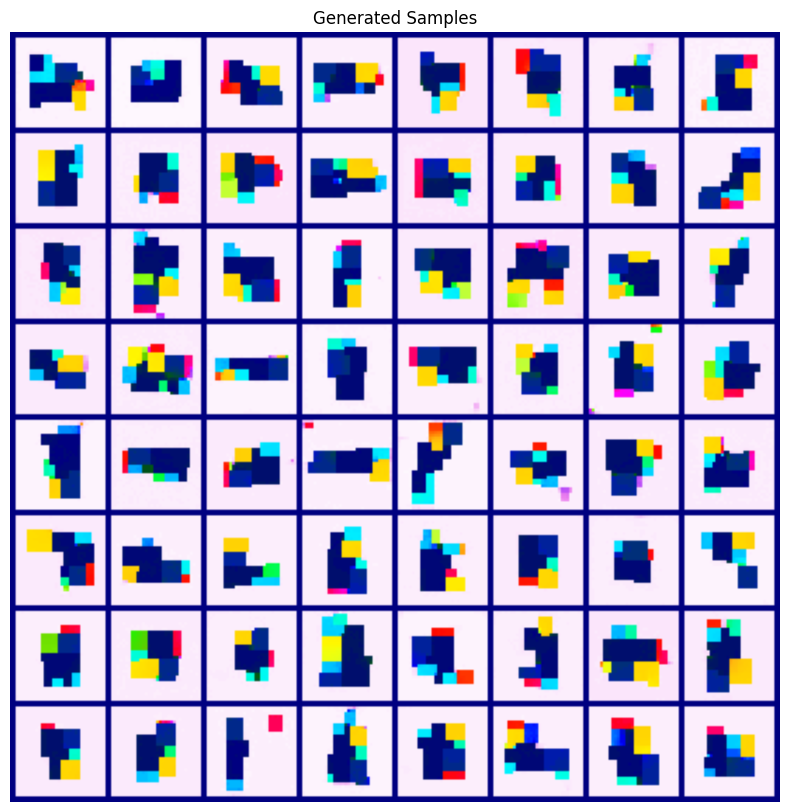

In [3]:
# 2. Check what keys are in each file
print("Keys in model.safetensors:")
model_state = load_file('model.safetensors')
print(list(model_state.keys())[:5], "...")

print("\nKeys in ema.safetensors:")
ema_state = load_file('ema.safetensors')
print(list(ema_state.keys())[:5], "...")

# 3. Create model
net = UNet2DModel(
    sample_size=32,
    in_channels=1,
    out_channels=1,
    layers_per_block=4,
    block_out_channels=(128, 256, 512),
    down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
    attention_head_dim=8,
    norm_num_groups=32,
    act_fn="silu",
)
net.to(device)

# 4. Load model weights (use model.safetensors since ema was saved incorrectly)
net.load_state_dict(load_file('model.safetensors', device=str(device)))
net.eval()

# 5. Create scheduler and sample
scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2",
)

def sample(n_samples=16, num_inference_steps=100):
    scheduler.set_timesteps(num_inference_steps)
    x = torch.randn(n_samples, 1, 32, 32).to(device)

    for t in scheduler.timesteps:
        with torch.no_grad():
            noise_pred = net(x, t).sample
        x = scheduler.step(noise_pred, t, x).prev_sample

    return x

# 6. Generate and display
samples = sample(n_samples=64, num_inference_steps=100)
samples_display = (samples.cpu() + 1) / 2

plt.figure(figsize=(10, 10))
plt.imshow(
    torchvision.utils.make_grid(samples_display, nrow=8)[0].clip(0, 1),
    cmap='gist_ncar'
)
plt.axis('off')
plt.title('Generated Samples')
plt.show()